In [39]:
#hi this is rylans skewt 

import matplotlib.pyplot as plt # bringing in necessary libraries
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

########## isolating my constants #############
g = 9.81 # m/s^2
Cp = 1004 # J/kgK 
Rd = 287 # J/kgK
Lv = 2.5e6 # J/kg
Rv = 461.5 # J/kgK

###############################################
def skewT(temp, pres, skew=-40): #I like 40 - defining skew here
#’’’
#Skews the temperature axis for a SkewT plot.
##temp: temperature values (deg C)
##pres: pressure values (hPa) whyd this part have to be commented out
###skew: amount of skew (default of -20)
    return (temp) + skew * np.log(pres/1000.0)



#  lets try dry adiabats

#we are in pressure space, so I guess lets plot potential temperature as the dry adiabats. I assume I can set one potential temp and find temp at each pressure

def isentrope(theta0):

    theta = theta0 + 273.15 # converting to kelvin
    p0 = 1000
    pf = 100
    oneisentrope = np.arange(p0, pf, -1) # basically making for one single isentrope, the pressure values from 1000 to 100 hPa and finding 
    # temp given pressure and potential temp 

    return theta * (oneisentrope/p0)**(Rd/Cp) - 273.15 # basically solving for temperature from theta



#now for the moist adiabats. cant quite use the one in the notes because thats relative to z not p, so I will integrate hydrostatic to eliminate z

def moist(T): # for an initial temperature
    p0 = 1000 # hPa
    Tk = T + 273.15 # converting to kelvin
    pressure = p0

    finaltemps = []

    while pressure > 100:

        es = 6.112 * np.exp(17.67 * (Tk - 273.15)/(Tk - 29.65)) # saturation vapor pressure in hPa

        rs = (Rd/Rv) * (es/(pressure - es)) # saturation mixing ratio in kg/kg

        gamma = (Rd*Tk/(Cp*pressure))*((1+(Lv*rs/(Rd*Tk)))/(1+(Lv**2*rs/(Cp*Rv*Tk**2)))) # moist adiabatic lapse rate in K/hPa - adjusted it by using hydrostatic equation to get rid of dz
        finaltemps.append(Tk - 273.15) # appending the temperature in celsius to the list
        Tk -= gamma # updating the temperature in kelvin
        pressure -= 1
    return finaltemps




Text(0.5, 1.0, 'Dry adiabats, proof of concept')

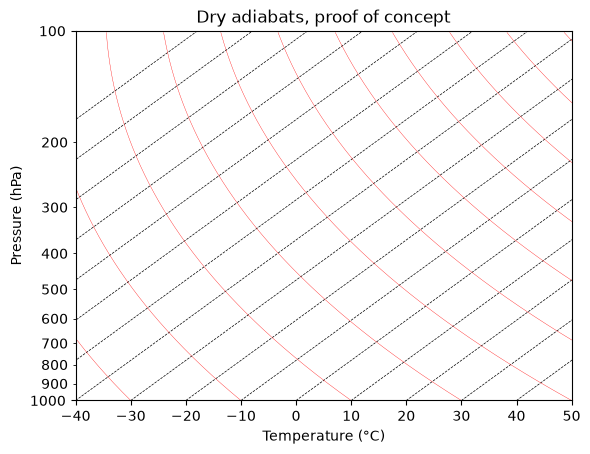

In [40]:
fig, ax = plt.subplots() # generating new figure for proof of concept
ax.semilogy() #log based axis for pressure
ax.set_ylim(1000, 100)
ax.yaxis.set_minor_formatter(mticker.ScalarFormatter())
ax.yaxis.set_major_formatter(mticker.ScalarFormatter()) #getting both out of scientific notation
ax.set_ylabel('Pressure (hPa)')

ax.set_xlim(-40, 50)
ax.set_xlabel('Temperature (°C)')




for i in range(-110, 50, 10): # every 10 degc
    ax.plot(skewT(np.array([i, i]), np.array([1000, 100])), np.array([1000, 100]), color='black', linewidth=0.5, linestyle='--')




for thetaq in range(-30, 240, 20):
    ax.plot(skewT(isentrope(thetaq), np.arange(1000, 100, -1)), np.arange(1000, 100, -1), color='red', linewidth=0.25, label='Dry Adiabats' if thetaq == -30 else None) # only label the first one to avoid clutter

ax.set_title("Dry adiabats, proof of concept")


![Image](https://pressbooks-dev.oer.hawaii.edu/atmo/wp-content/uploads/sites/74/2018/06/Screen-Shot-2018-07-05-at-10.45.06-AM.png)
 Image courtsey of 
 [Roland Stull](https://www.eoas.ubc.ca/books/Practical_Meteorology/)

When comparing both images, we can see that our own calculation of the dry adiabats follow the adiabats in this case directly. The adiabats appear to perfectly follow the expected temperature and pressures according to Stull's diagram, thus establishing our proof of concept. Although we utilize different intervals for the dry adiabats, our values when approximating their adiabats line up directly with the example's, helping to ensure consistency with past research. 

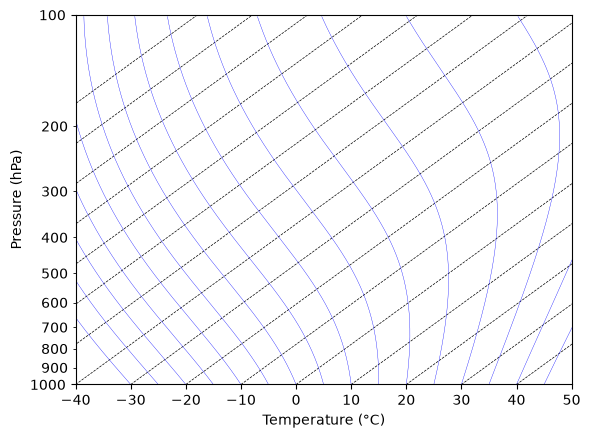

In [41]:
fig, ax = plt.subplots() # generating new figure for moist adiabatic proof of concept
ax.semilogy() #log based axis for pressure
ax.set_ylim(1000, 100)
ax.yaxis.set_minor_formatter(mticker.ScalarFormatter())
ax.yaxis.set_major_formatter(mticker.ScalarFormatter()) #getting both out of scientific notation
ax.set_ylabel('Pressure (hPa)')

ax.set_xlim(-40, 50)
ax.set_xlabel('Temperature (°C)')

for i in range(-110, 50, 10): # every 10 degc
    ax.plot(skewT(np.array([i, i]), np.array([1000, 100])), np.array([1000, 100]), color='black', linewidth=0.5, linestyle='--')


for T0 in range(-30, 50, 5, ):
    ax.plot(skewT(moist(T0), np.arange(1000, 100, -1)), np.arange(1000, 100, -1), color='blue', linewidth=0.25, label='Moist Adiabats' if T0 == -30 else None) # only label the first one to avoid clutter


![Image](https://pressbooks-dev.oer.hawaii.edu/atmo/wp-content/uploads/sites/74/2018/06/Screen-Shot-2018-07-05-at-10.45.20-AM.png)
Image courtsey of [Roland Stull](https://www.eoas.ubc.ca/books/Practical_Meteorology/)

Our moist adiabats can be verified to standards by again comparing to the Roland Stull chart of moist adiabats as a function of pressure and temperature. We can again compare values to check its validity. For example, the 20º adiabat crosses 0º at approximately 600 hPa, which lines up with our plot. The 30º adiabat also crosses 0º, but at around 400 hPa. Both of these line up with our own example, and all of the other values line up as well, confirming its validity. 

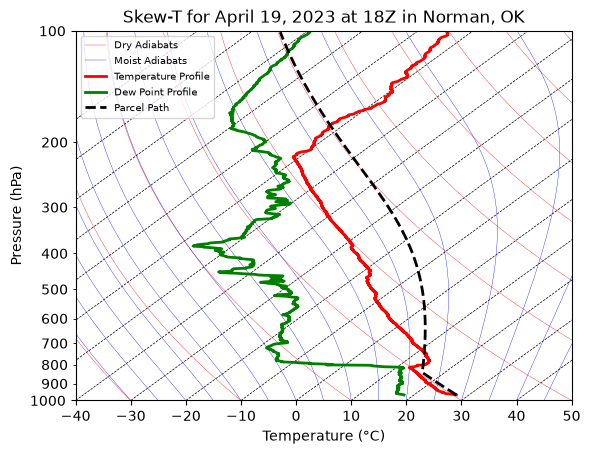

In [ ]:
fig, ax = plt.subplots() # generating new figure

ax.semilogy() #log based axis for pressure
ax.set_ylim(1000, 100)
ax.yaxis.set_minor_formatter(mticker.ScalarFormatter())
ax.yaxis.set_major_formatter(mticker.ScalarFormatter()) #getting both out of scientific notation
ax.set_ylabel('Pressure (hPa)')

ax.set_xlim(-40, 50)
ax.set_xlabel('Temperature (°C)')

#Now to start isotherms

for i in range(-110, 50, 10): # every 10 degc
    ax.plot(skewT(np.array([i, i]), np.array([1000, 100])), np.array([1000, 100]), color='black', linewidth=0.5, linestyle='--')

for thetaq in range(-30, 240, 20):
    ax.plot(skewT(isentrope(thetaq), np.arange(1000, 100, -1)), np.arange(1000, 100, -1), color='red', linewidth=0.25, label='Dry Adiabats' if thetaq == -30 else None) # only label the first one to avoid clutter

for T0 in range(-30, 50, 5, ):
    ax.plot(skewT(moist(T0), np.arange(1000, 100, -1)), np.arange(1000, 100, -1), color='blue', linewidth=0.25, label='Moist Adiabats' if T0 == -30 else None) # only label the first one to avoid clutter


url = "https://weather.uwyo.edu/wsgi/sounding?datetime=2023-04-19%2018:00:00&id=72357&type=TEXT:CSV&src=BUFR" # downloading the csv from the website

df = pd.read_csv(url)

temps = df['temperature_C']
pressures = df['pressure_hPa'] #extracting rows of data from csv

dews = df['dew point temperature_C']
relh = df['relative humidity_%']
mixingratios = df['mixing ratio_g/kg']


ax.plot(skewT(temps, pressures), pressures, color='red', linewidth=2, label='Temperature Profile')
ax.plot(skewT(dews, pressures), pressures, color='green', linewidth=2, label='Dew Point Profile')
ax.set_title("Skew-T for April 19, 2023 at 18Z in Norman, OK")

#parcel path

p0 = pressures[0]
T0 = temps[0]
parcelpath = []
relh0 = relh[0]
mr0 = mixingratios[0]*1e-3 # convert to kg/kg
theta0 = (T0 + 273.15) * (1000/p0)**(Rd/Cp) #K

#just for fun, plotting the parcel path. 
while p0 > 100:
    while relh0 < 100:
        
        T0 = theta0 * (p0/1000)**(Rd/Cp) - 273.15 # deg c initially dry adiabatic
        parcelpath.append(T0)
        p0 -= 1
        esnew = 6.112 * np.exp(17.67 * (T0)/(T0 + 243.5)) # saturation vapor pressure in hPa
        enew = mr0*p0/(0.622 + mr0) # actual vapor pressure in hPa
        relh0 = enew/esnew * 100 # relative humidity in %
     
    Tk = T0 + 273.15 # convert current parcel temp to Kelvin for thermodynamic equations

    es = 6.112 * np.exp(17.67 * (T0)/(T0 + 243.5)) 

    rs = (Rd/Rv) * (es/(p0 - es)) # saturation mixing ratio in kg/kg

    gamma = (Rd*Tk/(Cp*p0))*((1+(Lv*rs/(Rd*Tk)))/(1+(Lv**2*rs/(Cp*Rv*Tk**2)))) # moist adiabatic lapse rate in K/Pa
    
    Tk -= gamma # updating parcel temperature in Kelvin (dp = -1 hPa)
    T0 = Tk - 273.15 # updating T0 in Celsius
    parcelpath.append(T0) # append parcel temperature in Celsius
    p0 -= 1

ax.plot(skewT(parcelpath, np.arange(pressures[0], 100, -1)), np.arange(pressures[0], 100, -1), color='black', linewidth=2, label='Parcel Path', linestyle='--')

#make legend for the plot
ax.legend(loc='upper left',fontsize = 7.5)


# Analysis questions

### Q1: Why does the moist adiabatic lapse rate, Γm = −dT /dz, generally increase as a saturated parcel ascends and cools?



A saturated parcel's lapse rate comes down to how much moisture is available to be condensed. At higher temperatures, the Clausius-Clapeyron equation demonstrates that air has a higher capacity for water vapor. Because a parcel must be saturated for it to be following the moist adiabatic lapse rate, this means that warmer air will condense much more water as it is cooling compared to air that is already cool. Therefore, warmer air will release a greater amount of latently stored heat, and as a result cool slower. During cooling, the saturation vapor pressure will continue decreasing alongside temperature, which ends up increasing the lapse rate until it is approximately dry adiabatic. At this point, the latent heat released by the water vapor is approximately negligible as there is very little water vapor contained in the air to begin with. 

### Q2: At a fixed pressure, how and why does Γm differ between warmer and colder moist adiabats?


At a fixed pressure, cooler moist adiabats are much steeper than warmer moist adiabats. The same reasoning for the previous question can apply here. At a fixed pressure, only temperature is allowed to vary. At cooler temperatures, the saturation vapor pressure is lower, meaning exponentially less water vapor is contained within the air parcel. Because of this, the air has much lower total latent heat available to be released, and therefore a steeper lapse rate closer to dry adiabatic. At higher temperatures, more latent heat is available with more water vapor present, and therefore a less steep lapse rate that is substantially different than that of dry adiabatic. 

### Q3: "Break” your SkewT: test a wide range of skew values and describe what happens to the plot. What does this test teach you about the value of skewing? No need to show your tests; just describe your interpretations

Without the presence of skew, our temperature axis would be vertical. However, because the environmental lapse rate is typically on the order of 7ºC/Km, this means for just the troposphere, we would need to cover an order of around 84º C. With a vertical temperature axis, this makes the chart much harder to read and more pointless. Specific lapse rates become tougher to distinguish, for example a 9º/Km vs a 6º/Km. Skewing, however, much more aesthetically vertically aligns our temperature contours. It essentially helps to somewhat counter the steep values of the lapse rates, giving us a better picture of the lapse rates with height. Rather than our plot occupying a large horizontal domain, it occupies a much more vertical domain on the graph without losing data due to things like zooming in. At too large skews however, I found that the moist adiabats became much more erratic due to the skew. The values were accurate, but it showed that the ideal skewing range was somewhere in the range of 20 to 50. I found 40 to be the most aesthetically pleasing. 

### Q4: Describe two features of the sounding you chose to plot that you find particularly interesting or useful. Refer to specific pressure levels or layers and explain the physical significance of each feature.

Because the sounding I chose to plot was in the mid afternoon, it gives a good illustration of what has happened since the morning within the boundary layer. At the surface, the temperature is notably warmer than the immediate air aloft, which is evident by the brief superadiabatic lapse rates in the lowest 20 hPa. Above this, the boundary layer is well defined from the surface up to approx 800 hPa. This is made clear by the lapse rates being approximately dry adiabatic, and the mixing ratio being conserved throughout the layer. This shows that mixing via thermals is ongoing at the time. Additionally, above this layer, an elevated mixed layer is sitting on top of the warm moist air near the surface. This is shown also by the steep lapse rates and conservation of mixing ratio with height from about 800 to 550 hPa. This is helping to hold back parcels of air from reaching their level of free convection, but as this is an 18z sounding, further heating and destabilization remains to be seen later in the day. 

### Q5: What was the most challenging step for this lab? How did you navigate it, and what was the solution? If you leaned on GenAI tools, how did they contribute to your work and how did you check the information they provided?

I found the most challenging step in this lab to be figuring out how to plot my different adiabats. It honestly didn't take me long to figure out how to do them, but I had to make sure I was in pressure coordinates the whole time. This involved putting hydrostatic into the moist adiabatic lapse rate and potential temperature into the dry adiabatic lapse rate rather than just 9.8 K/km. I did not heavily lean on genAI tools, but the agent within vscode made some suggestions every once in a while when I was debugging that would be of use. It honestly scared me a little bit sometimes how it seemed to know what I was thinking of trying to do. I would not say they really provided my information but just made small syntax fixes, and thus didn't need to be cross-checked as they would with things like references. 